<a href="https://www.kaggle.com/code/ranimbenamara/tounum-automated-image-captioning-pipeline?scriptVersionId=314399020" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Full Pipeline

In [1]:
import os, json
import numpy as np
import tensorflow as tf

ARTIFACT_DIR = "/kaggle/input/models/ranimbenamara/tounum-image-pipeline/tensorflow2/v1/1"

def must_exist(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")

D1_MODEL_PATH = os.path.join(ARTIFACT_DIR, "deliverable1.keras")
D2_MODEL_PATH = os.path.join(ARTIFACT_DIR, "deliverable2_denoiser_model.keras")
CAP_WEIGHTS_PATH = os.path.join(ARTIFACT_DIR, "model.weights.h5")
CAP_VOCAB_PATH = os.path.join(ARTIFACT_DIR, "text_vocab.json")

for p in [D1_MODEL_PATH, D2_MODEL_PATH, CAP_WEIGHTS_PATH, CAP_VOCAB_PATH]:
    must_exist(p)

print("All model files found.")
print("TensorFlow:", tf.__version__)


2026-04-25 16:39:05.979108: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777135146.195564      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777135146.253312      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777135146.739467      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777135146.739510      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777135146.739516      23 computation_placer.cc:177] computation placer alr

All model files found.
TensorFlow: 2.19.0


In [2]:
classifier = tf.keras.models.load_model(D1_MODEL_PATH)
print("Deliverable 1 classifier loaded.")

denoiser = tf.keras.models.load_model(D2_MODEL_PATH, compile=False)
print("Deliverable 2 denoiser loaded.")


I0000 00:00:1777135172.321163      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Deliverable 1 classifier loaded.
Deliverable 2 denoiser loaded.


In [3]:
MAX_LENGTH = 40
VOCABULARY_SIZE = 15000
EMBEDDING_DIM = 512
UNITS = 512

vocab = json.load(open(CAP_VOCAB_PATH, "r"))

tokenizer = tf.keras.layers.TextVectorization(
    max_tokens=VOCABULARY_SIZE,
    standardize=None,
    output_sequence_length=MAX_LENGTH,
)
tokenizer.set_vocabulary(vocab)

idx2word = tf.keras.layers.StringLookup(
    mask_token="",
    vocabulary=tokenizer.get_vocabulary(),
    invert=True
)

print("Tokenizer restored. Vocab size:", tokenizer.vocabulary_size())


Tokenizer restored. Vocab size: 11796


In [4]:
def CNN_Encoder():
    inception_v3 = tf.keras.applications.InceptionV3(include_top=False, weights="imagenet")
    output = inception_v3.output
    output = tf.keras.layers.Reshape((-1, output.shape[-1]))(output)
    return tf.keras.models.Model(inception_v3.input, output)

class TransformerEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.layer_norm_1 = tf.keras.layers.LayerNormalization()
        self.layer_norm_2 = tf.keras.layers.LayerNormalization()
        self.attention = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.dense = tf.keras.layers.Dense(embed_dim, activation="relu")

    def call(self, x, training=False):
        x = self.layer_norm_1(x)
        x = self.dense(x)
        attn_output = self.attention(query=x, value=x, key=x, attention_mask=None, training=training)
        x = self.layer_norm_2(x + attn_output)
        return x

class Embeddings(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embed_dim, max_len):
        super().__init__()
        self.token_embeddings = tf.keras.layers.Embedding(vocab_size, embed_dim)
        self.position_embeddings = tf.keras.layers.Embedding(max_len, embed_dim)

    def call(self, input_ids):
        length = tf.shape(input_ids)[-1]
        position_ids = tf.range(start=0, limit=length, delta=1)
        position_ids = tf.expand_dims(position_ids, axis=0)
        token_embeddings = self.token_embeddings(input_ids)
        position_embeddings = self.position_embeddings(position_ids)
        return token_embeddings + position_embeddings

class TransformerDecoderLayer(tf.keras.layers.Layer):
    def __init__(self, embed_dim, units, num_heads):
        super().__init__()
        self.embedding = Embeddings(tokenizer.vocabulary_size(), embed_dim, MAX_LENGTH)

        self.attention_1 = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim, dropout=0.1)
        self.attention_2 = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim, dropout=0.1)

        self.layernorm_1 = tf.keras.layers.LayerNormalization()
        self.layernorm_2 = tf.keras.layers.LayerNormalization()
        self.layernorm_3 = tf.keras.layers.LayerNormalization()

        self.ffn_layer_1 = tf.keras.layers.Dense(units, activation="relu")
        self.ffn_layer_2 = tf.keras.layers.Dense(embed_dim)

        self.out = tf.keras.layers.Dense(tokenizer.vocabulary_size(), activation="softmax")

        self.dropout_1 = tf.keras.layers.Dropout(0.3)
        self.dropout_2 = tf.keras.layers.Dropout(0.5)

    def get_causal_attention_mask(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size, sequence_length = input_shape[0], input_shape[1]
        i = tf.range(sequence_length)[:, tf.newaxis]
        j = tf.range(sequence_length)
        mask = tf.cast(i >= j, dtype="int32")
        mask = tf.reshape(mask, (1, sequence_length, sequence_length))
        mult = tf.concat([tf.expand_dims(batch_size, -1), tf.constant([1, 1], dtype=tf.int32)], axis=0)
        return tf.tile(mask, mult)

    def call(self, input_ids, encoder_output, training=False, mask=None):
        embeddings = self.embedding(input_ids)
        combined_mask = None
        padding_mask = None

        if mask is not None:
            causal_mask = self.get_causal_attention_mask(embeddings)
            padding_mask = tf.cast(mask[:, :, tf.newaxis], dtype=tf.int32)
            combined_mask = tf.cast(mask[:, tf.newaxis, :], dtype=tf.int32)
            combined_mask = tf.minimum(combined_mask, causal_mask)

        attn_output_1 = self.attention_1(
            query=embeddings, value=embeddings, key=embeddings,
            attention_mask=combined_mask, training=training
        )
        out_1 = self.layernorm_1(embeddings + attn_output_1)

        attn_output_2 = self.attention_2(
            query=out_1, value=encoder_output, key=encoder_output,
            attention_mask=padding_mask, training=training
        )
        out_2 = self.layernorm_2(out_1 + attn_output_2)

        ffn_out = self.ffn_layer_1(out_2)
        ffn_out = self.dropout_1(ffn_out, training=training)
        ffn_out = self.ffn_layer_2(ffn_out)

        ffn_out = self.layernorm_3(ffn_out + out_2)
        ffn_out = self.dropout_2(ffn_out, training=training)
        return self.out(ffn_out)

class ImageCaptioningModel(tf.keras.Model):
    def __init__(self, cnn_model, encoder, decoder):
        super().__init__()
        self.cnn_model = cnn_model
        self.encoder = encoder
        self.decoder = decoder
        self.loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(reduction="none")
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.acc_tracker = tf.keras.metrics.Mean(name="accuracy")

    def call(self, inputs, training=False):
        imgs, captions = inputs
        img_embed = self.cnn_model(imgs, training=training)
        encoder_output = self.encoder(img_embed, training=training)
        y_input = captions[:, :-1]
        mask = y_input != 0
        return self.decoder(y_input, encoder_output, training=training, mask=mask)

    def calculate_loss(self, y_true, y_pred, mask):
        loss = self.loss_fn(y_true, y_pred)
        mask = tf.cast(mask, dtype=loss.dtype)
        loss *= mask
        return tf.reduce_sum(loss) / tf.reduce_sum(mask)

    def calculate_accuracy(self, y_true, y_pred, mask):
        accuracy = tf.equal(y_true, tf.argmax(y_pred, axis=2))
        accuracy = tf.math.logical_and(mask, accuracy)
        accuracy = tf.cast(accuracy, dtype=tf.float32)
        mask = tf.cast(mask, dtype=tf.float32)
        return tf.reduce_sum(accuracy) / tf.reduce_sum(mask)

    def compute_loss_and_acc(self, img_embed, captions):
        encoder_output = self.encoder(img_embed, training=True)
        y_input = captions[:, :-1]
        y_true = captions[:, 1:]
        mask = (y_true != 0)
        y_pred = self.decoder(y_input, encoder_output, training=True, mask=mask)
        loss = self.calculate_loss(y_true, y_pred, mask)
        acc = self.calculate_accuracy(y_true, y_pred, mask)
        return loss, acc

    def train_step(self, batch):
        imgs, captions = batch
        img_embed = self.cnn_model(imgs, training=False)

        with tf.GradientTape() as tape:
            loss, acc = self.compute_loss_and_acc(img_embed, captions)

        train_vars = self.encoder.trainable_variables + self.decoder.trainable_variables
        grads = tape.gradient(loss, train_vars)
        self.optimizer.apply_gradients(zip(grads, train_vars))

        self.loss_tracker.update_state(loss)
        self.acc_tracker.update_state(acc)
        return {"loss": self.loss_tracker.result(), "acc": self.acc_tracker.result()}

    @property
    def metrics(self):
        return [self.loss_tracker, self.acc_tracker]


In [5]:
encoder = TransformerEncoderLayer(EMBEDDING_DIM, 1)
decoder = TransformerDecoderLayer(EMBEDDING_DIM, UNITS, 8)
cnn_model = CNN_Encoder()
caption_model = ImageCaptioningModel(cnn_model, encoder, decoder)

_ = cnn_model(tf.zeros((1, 299, 299, 3), dtype=tf.float32))
_ = encoder(tf.zeros((1, 64, 2048), dtype=tf.float32))
_ = decoder(
    tf.zeros((1, MAX_LENGTH), dtype=tf.int32),
    tf.zeros((1, 64, EMBEDDING_DIM), dtype=tf.float32),
    training=False,
    mask=tf.ones((1, MAX_LENGTH), dtype=tf.bool),
)
_ = caption_model(
    (tf.zeros((1, 299, 299, 3), dtype=tf.float32), tf.zeros((1, MAX_LENGTH), dtype=tf.int32)),
    training=False,
)

caption_model.load_weights(CAP_WEIGHTS_PATH)
print("Captioning model restored.")

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I0000 00:00:1777135176.470148      23 cuda_dnn.cc:529] Loaded cuDNN version 91002


Captioning model restored.


In [6]:
def preprocess_for_classifier(img_rgb):
    x = tf.image.resize(img_rgb, (128, 128))
    x = tf.cast(x, tf.float32) / 255.0
    return tf.expand_dims(x, 0)

def preprocess_for_denoiser(img_rgb):
    x = tf.image.resize(img_rgb, (128, 128))
    x = tf.cast(x, tf.float32) / 255.0
    return tf.expand_dims(x, 0)

def preprocess_for_caption(denoised_01):
    x = tf.image.resize(denoised_01[0], (299, 299))
    x = x * 255.0
    x = tf.keras.applications.inception_v3.preprocess_input(x)
    return tf.expand_dims(tf.cast(x, tf.float32), 0)

def generate_caption(img_299_preprocessed):
    img_embed = caption_model.cnn_model(img_299_preprocessed)
    img_encoded = caption_model.encoder(img_embed, training=False)

    y_inp = "[start]"
    for i in range(MAX_LENGTH - 1):
        tokenized = tokenizer([y_inp])[:, :-1]
        mask = tf.cast(tokenized != 0, tf.int32)

        pred = caption_model.decoder(tokenized, img_encoded, training=False, mask=mask)
        pred_idx = int(np.argmax(pred[0, i, :]))
        pred_word = idx2word(tf.constant(pred_idx)).numpy().decode("utf-8")

        if pred_word == "[end]":
            break
        y_inp += " " + pred_word

    return y_inp.replace("[start] ", "").strip()


In [7]:
import matplotlib.pyplot as plt

def run_full_pipeline_visual(image_path):
    b = tf.io.read_file(image_path)
    img = tf.io.decode_image(b, channels=3, expand_animations=False)
    img_rgb = tf.cast(img, tf.float32)

    x_cls = preprocess_for_classifier(img_rgb)
    prob_photo = float(classifier.predict(x_cls, verbose=0)[0][0])
    is_photo = prob_photo >= 0.5
    cls_text = "Photo" if is_photo else "Not photo"
    cls_line = f"{cls_text} (prob={prob_photo:.2f})"

    x_den = preprocess_for_denoiser(img_rgb)
    den = denoiser.predict(x_den, verbose=0)

    x_cap = preprocess_for_caption(den)
    caption = generate_caption(x_cap)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(tf.clip_by_value(img_rgb / 255.0, 0, 1))
    plt.title("Original")
    plt.axis("off")
    plt.xlabel(cls_line)

    plt.subplot(1, 2, 2)
    plt.imshow(np.clip(den[0], 0, 1))
    plt.title("Denoised")
    plt.axis("off")
    plt.xlabel("Caption: " + caption)

    plt.tight_layout()
    plt.show()

    return {"is_photo": bool(is_photo), "photo_prob": prob_photo, "caption": caption}


I0000 00:00:1777135184.304334      68 service.cc:152] XLA service 0x781d24005ff0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777135184.304390      68 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1777135184.811635      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


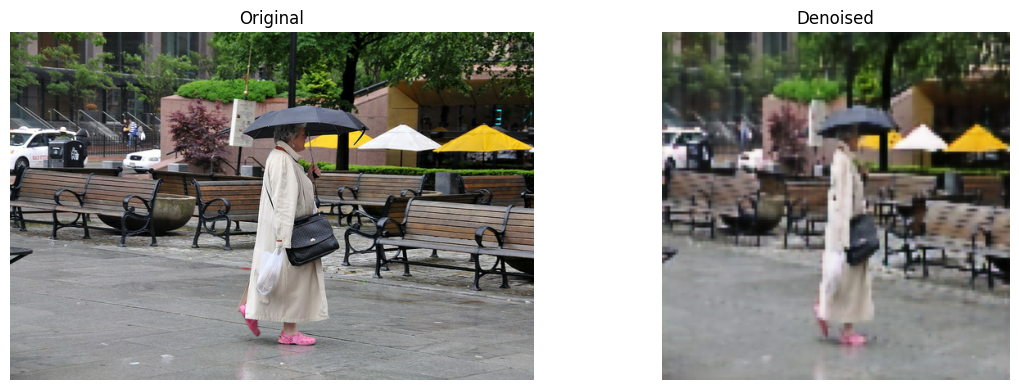

{'is_photo': False,
 'photo_prob': 0.00399077869951725,
 'caption': 'a man in a suit and tie on a bench'}

In [8]:
result = run_full_pipeline_visual("/kaggle/input/datasets/ranimbenamara/dataset-livrable-1/Dataset Livrable 1 - Photo/photo_4394.jpg")
result
